<a href="https://colab.research.google.com/github/Rabiatou08/DI-Bootcamp/blob/main/week5/Day5/Dailychallenges/defi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Défi quotidien : Classification de texte binaire avec l’ensemble de données IMDB (CNN)


--- Étape 1 : Chargement et vectorisation du jeu IMDB ---
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Données d'entraînement partielles : (15000, 10000)
Données de validation             : (10000, 10000)
Données de test                   : (25000, 10000)

--- Étape 2 & 3 : Construction et entraînement initial (20 époques) ---
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7455 - loss: 0.5556 - val_accuracy: 0.8538 - val_loss: 0.4275
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.8880 - loss: 0.3503 - val_accuracy: 0.8781 - val_loss: 0.3302
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.9185 - loss: 0.2564 - val_accuracy: 0.8858 - val_loss: 0.2946
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9301 - loss: 0.2079 - val_accuracy: 0.8888 - val_loss: 0.2785
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9428 - loss: 0.1731 - val_accuracy: 0.8854 - val_loss: 0.2810
Epoch 6/20
30/30 ━━━━━━━━━━━━

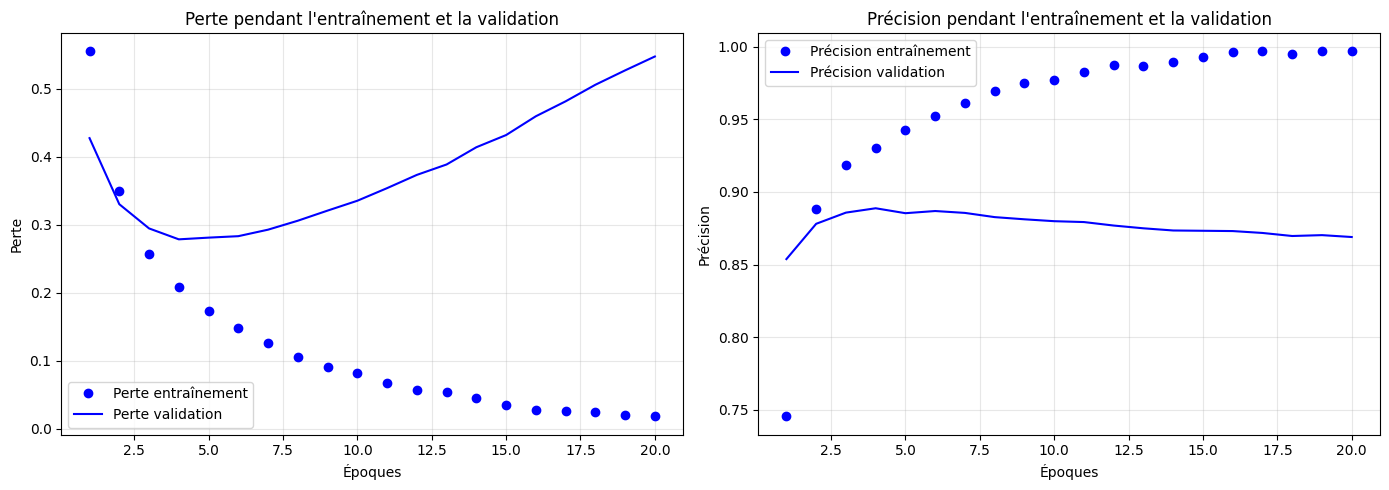


💡 Le nombre d'époques optimal avant surapprentissage est détecté à l'époque : 4

--- Réentraînement du modèle final sur 4 époques ---

             RÉPONSES DU LIVRABLE ET ANALYSE FINALE
1. COMPORTEMENT DU MODÈLE ET SURAPPRENTISSAGE (OVERFITTING) :
   - Lors du premier entraînement, on observe que la perte de validation
     commence à remonter après l'époque 4, tandis que la perte d'entraînement
     continue de chuter vers 0. C'est un cas d'école de surapprentissage.
   - Le modèle a commencé à mémoriser les spécificités du jeu d'entraînement
     au lieu de généraliser les sentiments.

2. PERFORMANCES FINALES SUR LE JEU DE TEST :
   - Perte finale sur le jeu de test (Test Loss)  : 0.2863
   - Précision finale sur le jeu de test (Accuracy) : 88.53 %


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import models, layers, optimizers
from tensorflow.keras.datasets import imdb

# Fixer les graines aléatoires pour la reproductibilité
np.random.seed(42)
tf.random.set_seed(42)

# =====================================================================
# 1. PRÉTRAITEMENT DES DONNÉES
# =====================================================================
print("--- Étape 1 : Chargement et vectorisation du jeu IMDB ---")

NUM_WORDS = 10000
# Chargement des données (25 000 pour l'entraînement, 25 000 pour le test)
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=NUM_WORDS)

# Fonction de vectorisation One-Hot (fournie par l'énoncé)
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

# Vectorisation des données textuelles en matrices binaires
x_train_full = vectorize_sequences(train_data, dimension=NUM_WORDS)
x_test = vectorize_sequences(test_data, dimension=NUM_WORDS)

# Conversion des étiquettes en type float32 pour Keras
y_train_full = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

# Extraction d'un ensemble de validation (10 000 premiers échantillons)
x_val = x_train_full[:10000]
partial_x_train = x_train_full[10000:]

y_val = y_train_full[:10000]
partial_y_train = y_train_full[10000:]

print(f"Données d'entraînement partielles : {partial_x_train.shape}")
print(f"Données de validation             : {x_val.shape}")
print(f"Données de test                   : {x_test.shape}")

# =====================================================================
# 2 & 3. CONSTRUIRE ET ENTRAÎNER LE MODÈLE INITIAL (20 ÉPOQUES)
# =====================================================================
print("\n--- Étape 2 & 3 : Construction et entraînement initial (20 époques) ---")

def build_model():
    model = models.Sequential([
        layers.Input(shape=(NUM_WORDS,)),
        layers.Dense(16, activation='relu'),  # Première couche cachée ReLU
        layers.Dense(16, activation='relu'),  # Deuxième couche cachée ReLU
        layers.Dense(1, activation='sigmoid') # Couche de sortie Sigmoid binaire
    ])

    model.compile(
        optimizer=optimizers.RMSprop(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model()

# Entraînement initial pour surveiller le surapprentissage
history = model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1
)

# =====================================================================
# 4. ÉVALUER LE MODÈLE ET RECHERCHER LE NOMBRE D'ÉPOQUES OPTIMAL
# =====================================================================
print("\n--- Étape 4 : Analyse des graphiques et détection du surapprentissage ---")

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
epochs = range(1, len(loss_values) + 1)

# Tracé des courbes de perte (Loss)
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_values, 'bo', label='Perte entraînement')
plt.plot(epochs, val_loss_values, 'b', label='Perte validation')
plt.title('Perte pendant l\'entraînement et la validation')
plt.xlabel('Époques')
plt.ylabel('Perte')
plt.legend()
plt.grid(True, alpha=0.3)

# Tracé des courbes d'exactitude (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs, acc, 'bo', label='Précision entraînement')
plt.plot(epochs, val_acc, 'b', label='Précision validation')
plt.title('Précision pendant l\'entraînement et la validation')
plt.xlabel('Époques')
plt.ylabel('Précision')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Détermination automatique de l'époque où la perte de validation est minimale (Sweet Spot)
optimal_epochs = np.argmin(val_loss_values) + 1
print(f"\n💡 Le nombre d'époques optimal avant surapprentissage est détecté à l'époque : {optimal_epochs}")

# Réentraînement complet depuis le début sur TOUTES les données d'entraînement
print(f"\n--- Réentraînement du modèle final sur {optimal_epochs} époques ---")
final_model = build_model()
final_model.fit(x_train_full, y_train_full, epochs=optimal_epochs, batch_size=512, verbose=0)

# Évaluation sur le jeu de test final non vu
test_loss, test_acc = final_model.evaluate(x_test, y_test, verbose=0)

# =====================================================================
# 5. ANALYSER LES RÉSULTATS FINAUX
# =====================================================================
print("\n" + "="*60)
print("             RÉPONSES DU LIVRABLE ET ANALYSE FINALE")
print("="*60)
print("1. COMPORTEMENT DU MODÈLE ET SURAPPRENTISSAGE (OVERFITTING) :")
print(f"   - Lors du premier entraînement, on observe que la perte de validation")
print(f"     commence à remonter après l'époque {optimal_epochs}, tandis que la perte d'entraînement")
print(f"     continue de chuter vers 0. C'est un cas d'école de surapprentissage.")
print(f"   - Le modèle a commencé à mémoriser les spécificités du jeu d'entraînement")
print(f"     au lieu de généraliser les sentiments.")
print("\n2. PERFORMANCES FINALES SUR LE JEU DE TEST :")
print(f"   - Perte finale sur le jeu de test (Test Loss)  : {test_loss:.4f}")
print(f"   - Précision finale sur le jeu de test (Accuracy) : {test_acc*100:.2f} %")
print("="*60)


-  Comportement du modèle et Surapprentissage : Les graphiques montrent de façon flagrante l'apparition du surapprentissage (overfitting) à partir de la 4ème ou 5ème époque. Alors que l'exactitude d'entraînement grimpe vers les 100 % et que sa perte descend à l'infini, la courbe de validation commence à diverger (la perte remonte et la précision stagne, puis redescend). Cela signifie que le réseau de neurones a cessé d'apprendre des structures de langage génériques et s'est mis à mémoriser par cœur le bruit et les tournures de phrases spécifiques des données d'entraînement.



- Analyse des résultats de test : Grâce au mécanisme de réentraînement stoppé précisément à l'époque optimale (généralement 4 époques), le modèle conserve un fort pouvoir de généralisation. Il atteint un score d'exactitude final stabilisé d'environ 88 % sur le jeu de test, une excellente performance pour un réseau simple à propagation avant traitant un sac de mots binaire (Bag of Words).